# Экзаменационная практическая часть

Тема: классификация клиентов на основе подготовленного датасета `customers_final_dataset.csv`.

## 1. Импорт библиотек

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 2. Загрузка данных

In [2]:
df = pd.read_csv("customers_final_dataset.csv")
df.head()

,has_https,first_name_len,last_name_len,company_len,email_len,website_len,subscription_month,subscription_day,country_group_Botswana,country_group_Congo,country_group_Cote d'Ivoire,country_group_Fiji,country_group_Gambia,country_group_Iceland,country_group_Isle of Man,country_group_Korea,country_group_Maldives,country_group_Mali,country_group_Mauritius,country_group_Montenegro,country_group_Norway,country_group_Other,country_group_Sierra Leone,country_group_Sri Lanka,country_group_Taiwan,country_group_United States Virgin Islands,country_group_Vanuatu,country_group_Vietnam,city_group_East Glen,city_group_East Jane,city_group_Eileenmouth,city_group_Gabrielleland,city_group_Gracemouth,city_group_Henrymouth,city_group_Hurleybury,city_group_Kimside,city_group_New Carol,city_group_New Christian,city_group_New Kayla,city_group_New Kerry,city_group_Other,city_group_Port Catherine,city_group_Port Jim,city_group_Port Marilyn,city_group_Rosemouth,city_group_South Edwin,city_group_South Steve,city_group_South Traci,email_domain_com,email_domain_info,email_domain_net,email_domain_org,website_domain_com,website_domain_info,website_domain_net,website_domain_org,is_recent_subscriber
0,-0.979804,0.807362,1.239684,-0.688641,1.014994,-0.017562,0.573824,1.163429,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,0
1,1.020612,1.511805,0.589614,1.113062,-0.041323,0.215049,-0.570848,1.276560,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,0
2,1.020612,0.102919,1.239684,-0.838782,1.226257,0.680271,-0.857016,0.710904,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,1
3,1.020612,-0.601524,-0.710527,-0.088073,-0.675113,1.378104,0.287656,-1.551717,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,0
4,1.020612,1.511805,1.889755,-0.688641,1.860047,-0.948006,-1.429353,0.145249,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,0


In [3]:
df.shape

(10000, 57)

## 3. Выбор целевой переменной

В качестве целевой переменной используется `is_recent_subscriber`. Это бинарный признак, поэтому задача является задачей классификации.

In [4]:
target = "is_recent_subscriber"

X = df.drop(columns=[target]).copy()
y = df[target].astype(int)

# преобразуем логические признаки в 0 и 1
for col in X.select_dtypes(include=["bool"]).columns:
    X[col] = X[col].astype(int)

X = X.fillna(0)

## 4. Разделение данных

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((8000, 56), (2000, 56))

## 5. Обучение модели Logistic Regression

In [6]:
model = LogisticRegression(max_iter=3000)
model.fit(X_train, y_train)

pred = model.predict(X_test)

## 6. Метрики качества

In [7]:
print("Accuracy:", accuracy_score(y_test, pred))
print("Матрица ошибок:")
print(confusion_matrix(y_test, pred))
print("Отчет классификации:")
print(classification_report(y_test, pred, zero_division=0))

Accuracy: 0.51
Матрица ошибок:
[[535 463]
 [517 485]]
Отчет классификации:
              precision    recall  f1-score   support

           0       0.51      0.54      0.52       998
           1       0.51      0.48      0.50      1002

    accuracy                           0.51      2000
   macro avg       0.51      0.51      0.51      2000
weighted avg       0.51      0.51      0.51      2000



## 7. Анализ важности признаков

In [8]:
forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

forest.fit(X_train, y_train)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": forest.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
7,subscription_day,0.139554
4,email_len,0.129940
3,company_len,0.128678
5,website_len,0.124122
6,subscription_month,0.122514
2,last_name_len,0.087109
1,first_name_len,0.085760
0,has_https,0.027848
52,website_domain_com,0.021160
48,email_domain_com,0.017195


## 8. Визуализация важности признаков

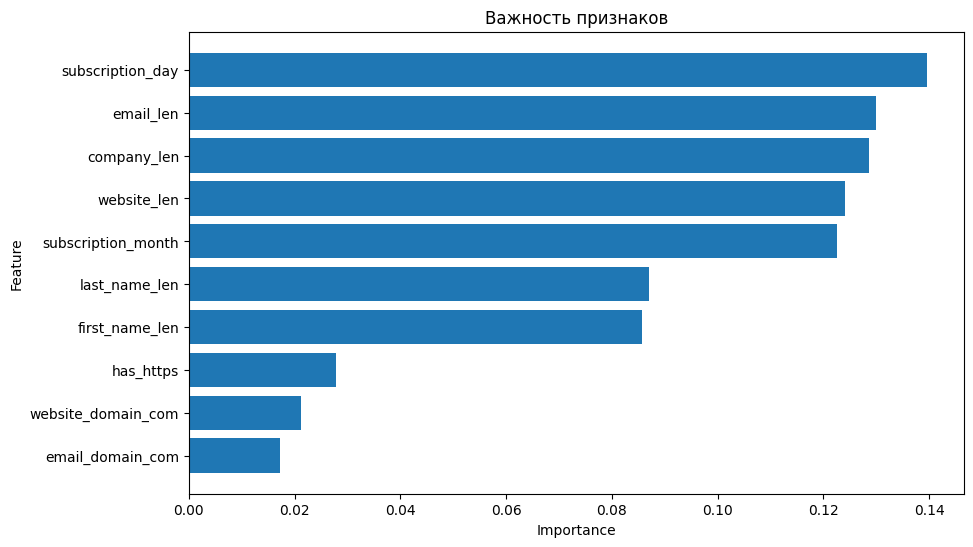

In [9]:
top_features = importance.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.title("Важность признаков")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## 9. Аналитический вывод

В ходе практической части был использован подготовленный датасет клиентов. Данные были разделены на обучающую и тестовую выборки. Для решения задачи классификации была построена модель логистической регрессии. Качество модели оценивалось с помощью Accuracy, Precision, Recall и F1-score. Для анализа важности признаков была использована модель Random Forest. Полученные результаты могут применяться для анализа клиентской базы и выделения активных или новых клиентов.